## 🧠 Actionable vs Non‑Actionable Social Media Posts Classifier DL Model Using LSTM 

🎯 **Use Case:** Automatically identify posts that require action by support teams.

**Label:**
- 1 → Actionable (Needs response)
- 0 → Non‑Actionable


### 📦 Import Libraries

In [ ]:
import pandas as pd                      # Data handling
import numpy as np                       # Numerical operations
import re                                # Text processing
import matplotlib.pyplot as plt          # Data visualization

from sklearn.model_selection import train_test_split      # Split train/test data
from sklearn.feature_extraction.text import TfidfVectorizer  # Convert text to numbers
from sklearn.metrics import accuracy_score, classification_report  # Model evaluation

from tensorflow.keras.models import Sequential            # Neural network model
from tensorflow.keras.layers import LSTM, Dense, Dropout # Deep learning layers

### 📂 Load Dataset

In [ ]:
df = pd.read_csv("actionable_social_media_posts.csv")  # Load CSV file into DataFrame
df.head()                                              # Show first 5 rows of dataset

,post_text,actionable
0,Nice update well done team,0
1,Ticket booked amount debited but no confirmation,1
2,This app looks clean and modern,0
3,Nice update well done team,0
4,Nice update well done team,0


### 🔍 Text Preprocessing

In [ ]:
def clean_text(text):                              # Function to clean text data
    text = text.lower()                            # Convert text to lowercase
    text = re.sub(r"[^a-zA-Z ]", "", text)         # Remove numbers, symbols, punctuation
    return text                                    # Return cleaned text

df["clean_text"] = df["post_text"].apply(clean_text)  # Apply cleaning to post_text column
df.head()                                             # Show first 5 rows

,post_text,actionable,clean_text
0,Nice update well done team,0,nice update well done team
1,Ticket booked amount debited but no confirmation,1,ticket booked amount debited but no confirmation
2,This app looks clean and modern,0,this app looks clean and modern
3,Nice update well done team,0,nice update well done team
4,Nice update well done team,0,nice update well done team


### 📊 Target Distribution

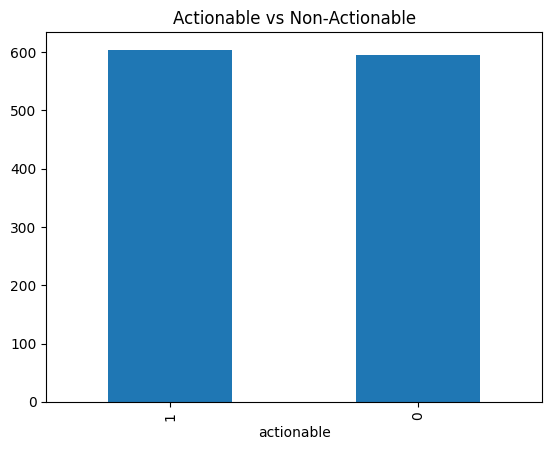

In [ ]:
df["actionable"].value_counts().plot(kind="bar", title="Actionable vs Non-Actionable")  # Plot class counts as bar chart
plt.show()                                                                               # Display chart

### 🧪 Train–Test Split

In [ ]:
X = df["clean_text"]          # Select cleaned text as input features
y = df["actionable"]          # Select target labels (actionable / non-actionable)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,                     # Input features and target labels
    test_size=0.2,           # Use 20% data for testing
    random_state=42          # Fix random split for same results every run
)

### 🧠 TF‑IDF Feature Engineering

In [ ]:
tfidf = TfidfVectorizer(max_features=150)            # Create TF-IDF vectorizer with top 150 words/features
X_train_tfidf = tfidf.fit_transform(X_train).toarray()  # Fit on training text and convert to numeric array
X_test_tfidf = tfidf.transform(X_test).toarray()        # Transform test text using same fitted vectorizer

### 🔄 Reshape for LSTM

In [ ]:
X_train_lstm = X_train_tfidf.reshape(
    X_train_tfidf.shape[0],   # Number of training samples
    X_train_tfidf.shape[1],   # Number of features (time steps)
    1                         # One feature per step for LSTM input
)

X_test_lstm = X_test_tfidf.reshape(
    X_test_tfidf.shape[0],    # Number of testing samples
    X_test_tfidf.shape[1],    # Number of features (time steps)
    1                         # One feature per step for LSTM input
)

### 🤖 Build LSTM Model

In [ ]:
X_train_lstm = X_train_tfidf.reshape(
    X_train_tfidf.shape[0], X_train_tfidf.shape[1], 1
)  # Reshape training data to 3D for LSTM: (samples, timesteps, features)

X_test_lstm = X_test_tfidf.reshape(
    X_test_tfidf.shape[0], X_test_tfidf.shape[1], 1
)  # Reshape testing data to 3D for LSTM: (samples, timesteps, features)


model = Sequential([                               # Create Sequential neural network model
    LSTM(64, input_shape=(X_train_lstm.shape[1], 1)),  # LSTM layer with 64 neurons
    Dropout(0.3),                                 # Drop 30% neurons to reduce overfitting
    Dense(1, activation="sigmoid")                # Output layer for binary classification
])

model.compile(
    loss="binary_crossentropy",   # Loss function for binary classes
    optimizer="adam",            # Adam optimizer for training
    metrics=["accuracy"]         # Track accuracy during training
)

model.summary()                  # Show model architecture summary

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

### 🚀 Train Model

In [ ]:
model.fit(
    X_train_lstm,            # Training input data
    y_train,                 # Training target labels
    epochs=10,               # Train model for 10 full rounds
    batch_size=32,           # Use 32 samples per batch
    validation_split=0.2     # Use 20% of training data for validation
)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.5086 - loss: 0.6935 - val_accuracy: 0.5208 - val_loss: 0.6937
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.4415 - loss: 0.6941 - val_accuracy: 0.4844 - val_loss: 0.6934
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5157 - loss: 0.6928 - val_accuracy: 0.4740 - val_loss: 0.6949
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.4973 - loss: 0.6938 - val_accuracy: 0.4740 - val_loss: 0.6938
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5313 - loss: 0.6924 - val_accuracy: 0.4740 - val_loss: 0.6942
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5024 - loss: 0.6934 - val_accuracy: 0.4740 - val_loss: 0.6934
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.4777 - loss: 0.6935 - val_accuracy: 0.4844 - val_loss: 0.6918
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5560 - loss: 0.6842 - val_accuracy: 0.5938 - v

### 📈 Evaluate Model

In [ ]:
y_pred = (model.predict(X_test_lstm) > 0.5).astype(int)  # Predict probabilities, convert >0.5 to class 1 else 0

print("Accuracy:", accuracy_score(y_test, y_pred))       # Print overall model accuracy
print(classification_report(y_test, y_pred))             # Print precision, recall, F1-score

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Accuracy: 0.6958333333333333
              precision    recall  f1-score   support

           0       0.68      0.67      0.68       114
           1       0.71      0.72      0.71       126

    accuracy                           0.70       240
   macro avg       0.70      0.69      0.69       240
weighted avg       0.70      0.70      0.70       240



### ✅ Takeaways

- Automatically filter posts needing action
- Reduce manual monitoring
- Improve response time
- Scalable for millions of posts